In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, CvtModel

from torchvision import models
import matplotlib.pyplot as plt

from data.datasets import DeepFakeDataset

/home/ocastaneda/anaconda3/envs/pytorch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
image_dir_path = 'Deepfake-Eval-2024/image-data'

train_data = DeepFakeDataset("image-metadata-train.csv", image_dir_path, 'ViT', is_train = True)
dataloader = DataLoader(train_data, batch_size = 32, shuffle = True)

torch.Size([32, 3, 224, 224])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


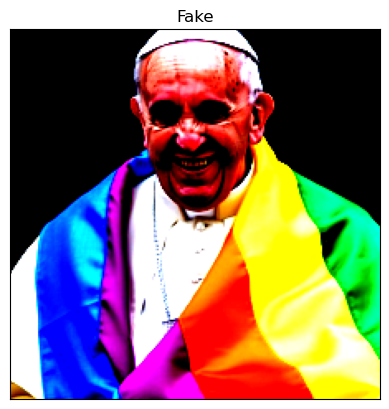

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.5877128].


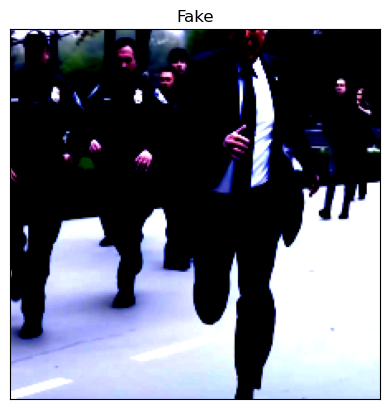

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


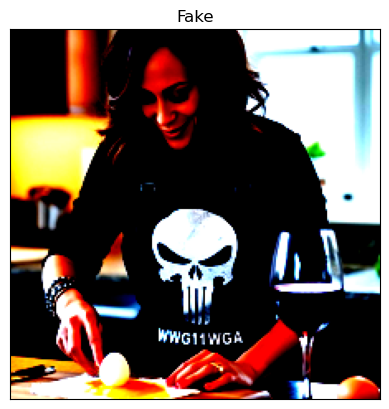

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.5005665].


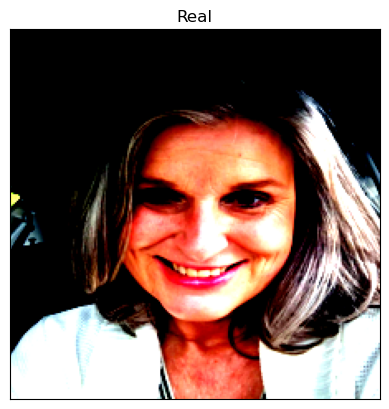

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].


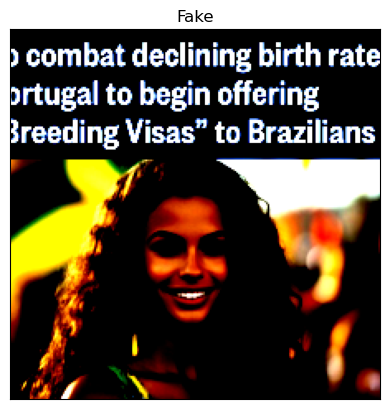

In [3]:
count = 0
features, label = next(iter(dataloader))
print(features.shape)
    # count += 1
    # if count < 5:
for i in range(5):
    img = features[i]
    plt.imshow(np.transpose(img, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title("Fake" if label[i] else "Real")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [4]:
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', weights="ResNet50_Weights.IMAGENET1K_V1")
# model.fc = nn.Identity()    # replace classification head with passthrough effectively removing last classification layer
# # extract features for train
# resnet_features = model(features)